In [2]:
# ===== RISK SCORING: DATA LOAD =====

import pandas as pd
import numpy as np

# 10K sales data
sales = pd.read_csv("../data/sales_10k_clean.csv")

# Inventory data
inventory = pd.read_csv(
    "../data/retail_clean_dataset/inventory_snapshot.csv"
)

# Convert date
sales["date"] = pd.to_datetime(
    sales["date"],
    errors="coerce"
)

print("===== RISK SCORING DATA =====")
print("Sales records:", len(sales))
print("Inventory records:", len(inventory))

print("\nSales columns:")
print(sales.columns.tolist())

print("\nInventory columns:")
print(inventory.columns.tolist())

===== RISK SCORING DATA =====
Sales records: 10000
Inventory records: 21228

Sales columns:
['date', 'receipt_id', 'store_id', 'sku_id', 'customer_id', 'quantity', 'unit_price', 'total_value', 'channel', 'discount_pct', 'promo_id']

Inventory columns:
['store_id', 'sku_id', 'stock_on_hand', 'reorder_point', 'safety_stock', 'last_restock_date']


In [3]:
# ===== ALIGN INVENTORY WITH 10K SALES UNIVERSE =====

sales_pairs = sales[
    ["store_id", "sku_id"]
].drop_duplicates()

inventory_10k = inventory.merge(
    sales_pairs,
    on=["store_id", "sku_id"],
    how="inner"
)

print("===== INVENTORY ALIGNED TO 10K SALES =====")
print("Unique sales store-SKU pairs:", len(sales_pairs))
print("Inventory records after alignment:", len(inventory_10k))

print("\nInventory sample:")
print(
    inventory_10k[
        [
            "store_id",
            "sku_id",
            "stock_on_hand",
            "reorder_point",
            "safety_stock"
        ]
    ].head(10)
)

===== INVENTORY ALIGNED TO 10K SALES =====
Unique sales store-SKU pairs: 8353
Inventory records after alignment: 1556

Inventory sample:
  store_id    sku_id  stock_on_hand  reorder_point  safety_stock
0     ST25  SKU00749            115             27            10
1     ST06  SKU04913              0             26             9
2     ST13  SKU03088              0             97            40
3     ST30  SKU04489              0             74            37
4     ST07  SKU02519            259             45             9
5     ST27  SKU01939            299             55            24
6     ST20  SKU02983              0             77            25
7     ST19  SKU03633              0             81            27
8     ST20  SKU02057            421             74            36
9     ST07  SKU01485              0             55            27


In [4]:
# ===== DEMAND METRICS =====

weekly_sku = (
    sales.groupby("sku_id")
    .resample("W", on="date")
    .agg(
        units_sold=("quantity", "sum"),
        revenue=("total_value", "sum"),
        transactions=("receipt_id", "nunique")
    )
    .reset_index()
)

avg_weekly_demand = (
    weekly_sku
    .groupby("sku_id")["units_sold"]
    .mean()
    .reset_index(name="avg_weekly_demand")
)

# Merge demand with inventory
risk_data = inventory_10k.merge(
    avg_weekly_demand,
    on="sku_id",
    how="left"
)

# Weeks of inventory available
risk_data["weeks_of_inventory"] = (
    risk_data["stock_on_hand"] /
    risk_data["avg_weekly_demand"].replace(0, np.nan)
)

print("===== RISK METRICS =====")
print("Risk records:", len(risk_data))
print("Unique SKUs:", risk_data["sku_id"].nunique())

print("\nAverage weekly demand:")
print(risk_data["avg_weekly_demand"].describe())

print("\nSample:")
print(
    risk_data[
        [
            "store_id",
            "sku_id",
            "stock_on_hand",
            "reorder_point",
            "safety_stock",
            "avg_weekly_demand",
            "weeks_of_inventory"
        ]
    ].head(10)
)

===== RISK METRICS =====
Risk records: 1556
Unique SKUs: 753

Average weekly demand:
count    1556.000000
mean        0.418743
std         0.799102
min         0.011236
25%         0.076923
50%         0.127230
75%         0.335079
max         5.531100
Name: avg_weekly_demand, dtype: float64

Sample:
  store_id    sku_id  stock_on_hand  reorder_point  safety_stock  \
0     ST25  SKU00749            115             27            10   
1     ST06  SKU04913              0             26             9   
2     ST13  SKU03088              0             97            40   
3     ST30  SKU04489              0             74            37   
4     ST07  SKU02519            259             45             9   
5     ST27  SKU01939            299             55            24   
6     ST20  SKU02983              0             77            25   
7     ST19  SKU03633              0             81            27   
8     ST20  SKU02057            421             74            36   
9     ST07  SKU014

In [5]:
# ===== BASIC INVENTORY RISK FLAGS =====

risk_data["stockout_risk"] = (
    risk_data["stock_on_hand"] <= 0
)

risk_data["below_safety_risk"] = (
    risk_data["stock_on_hand"] < risk_data["safety_stock"]
)

risk_data["reorder_risk"] = (
    risk_data["stock_on_hand"] <= risk_data["reorder_point"]
)

print("===== INVENTORY RISK FLAGS =====")

print(
    "Stockout risk:",
    risk_data["stockout_risk"].sum()
)

print(
    "Below safety stock:",
    risk_data["below_safety_risk"].sum()
)

print(
    "Reorder point risk:",
    risk_data["reorder_risk"].sum()
)

print("\nSample:")
print(
    risk_data[
        [
            "store_id",
            "sku_id",
            "stock_on_hand",
            "reorder_point",
            "safety_stock",
            "stockout_risk",
            "below_safety_risk",
            "reorder_risk"
        ]
    ].head(10)
)

===== INVENTORY RISK FLAGS =====
Stockout risk: 864
Below safety stock: 917
Reorder point risk: 1024

Sample:
  store_id    sku_id  stock_on_hand  reorder_point  safety_stock  \
0     ST25  SKU00749            115             27            10   
1     ST06  SKU04913              0             26             9   
2     ST13  SKU03088              0             97            40   
3     ST30  SKU04489              0             74            37   
4     ST07  SKU02519            259             45             9   
5     ST27  SKU01939            299             55            24   
6     ST20  SKU02983              0             77            25   
7     ST19  SKU03633              0             81            27   
8     ST20  SKU02057            421             74            36   
9     ST07  SKU01485              0             55            27   

   stockout_risk  below_safety_risk  reorder_risk  
0          False              False         False  
1           True               True  

In [6]:
# ===== FINAL RISK CATEGORY =====

risk_data["risk_category"] = np.select(
    [
        risk_data["stockout_risk"],
        risk_data["below_safety_risk"],
        risk_data["reorder_risk"]
    ],
    [
        "Critical Stockout",
        "High Risk",
        "Reorder Required"
    ],
    default="Healthy"
)

print("===== RISK CATEGORY SUMMARY =====")

risk_summary = (
    risk_data["risk_category"]
    .value_counts()
    .reset_index()
)

risk_summary.columns = [
    "risk_category",
    "record_count"
]

print(risk_summary)

===== RISK CATEGORY SUMMARY =====
       risk_category  record_count
0  Critical Stockout           864
1            Healthy           532
2   Reorder Required           107
3          High Risk            53


In [7]:
# ===== RECOMMENDED ACTION =====

risk_data["recommended_action"] = np.select(
    [
        risk_data["risk_category"] == "Critical Stockout",
        risk_data["risk_category"] == "High Risk",
        risk_data["risk_category"] == "Reorder Required"
    ],
    [
        "Immediate Reorder",
        "Expedite Replenishment",
        "Plan Reorder"
    ],
    default="No Immediate Action"
)

print("===== RECOMMENDED ACTION SUMMARY =====")

action_summary = (
    risk_data["recommended_action"]
    .value_counts()
    .reset_index()
)

action_summary.columns = [
    "recommended_action",
    "record_count"
]

print(action_summary)

===== RECOMMENDED ACTION SUMMARY =====
       recommended_action  record_count
0       Immediate Reorder           864
1     No Immediate Action           532
2            Plan Reorder           107
3  Expedite Replenishment            53


In [8]:
# ===== LATEST SEASONAL-NAIVE FORECAST =====

# Create weekly SKU demand
weekly_sku = (
    sales.groupby("sku_id")
    .resample("W", on="date")
    .agg(
        units_sold=("quantity", "sum"),
        revenue=("total_value", "sum"),
        transactions=("receipt_id", "nunique")
    )
    .reset_index()
)

# Create 52-week seasonal lag
weekly_sku["lag_52"] = (
    weekly_sku
    .groupby("sku_id")["units_sold"]
    .shift(52)
)

# Seasonal-naive forecast
weekly_sku["seasonal_naive_forecast"] = weekly_sku["lag_52"]

# Keep only records where forecast is available
baseline_data = weekly_sku[
    weekly_sku["seasonal_naive_forecast"].notna()
].copy()

# Latest forecast for each SKU
latest_forecast = (
    baseline_data
    .sort_values(["sku_id", "date"])
    .groupby("sku_id")
    .tail(1)
    [
        ["sku_id", "date", "seasonal_naive_forecast"]
    ]
    .copy()
)

latest_forecast = latest_forecast.rename(
    columns={
        "date": "forecast_reference_date",
        "seasonal_naive_forecast": "forecast_weekly_demand"
    }
)

print("===== LATEST SEASONAL-NAIVE FORECAST =====")
print("Forecast records:", len(latest_forecast))
print("Unique SKUs:", latest_forecast["sku_id"].nunique())

print("\nSample:")
print(latest_forecast.head(10))

===== LATEST SEASONAL-NAIVE FORECAST =====
Forecast records: 1470
Unique SKUs: 1470

Sample:
        sku_id forecast_reference_date  forecast_weekly_demand
173   SKU00001              2025-11-16                     0.0
376   SKU00002              2025-12-21                     0.0
439   SKU00004              2024-10-13                     0.0
594   SKU00005              2025-03-23                     0.0
714   SKU00006              2024-04-21                     0.0
923   SKU00010              2025-06-01                     0.0
1066  SKU00014              2025-08-31                     0.0
1232  SKU00016              2025-05-18                     0.0
1337  SKU00019              2024-09-08                     0.0
1531  SKU00020              2025-12-21                     0.0


In [9]:
# ===== MERGE FORECAST WITH INVENTORY =====

risk_data = risk_data.merge(
    latest_forecast[
        [
            "sku_id",
            "forecast_reference_date",
            "forecast_weekly_demand"
        ]
    ],
    on="sku_id",
    how="left"
)

print("===== FORECAST + INVENTORY =====")
print("Risk records:", len(risk_data))
print(
    "Records with forecast:",
    risk_data["forecast_weekly_demand"].notna().sum()
)
print(
    "Records without forecast:",
    risk_data["forecast_weekly_demand"].isna().sum()
)

print("\nSample:")
print(
    risk_data[
        [
            "store_id",
            "sku_id",
            "stock_on_hand",
            "reorder_point",
            "safety_stock",
            "avg_weekly_demand",
            "forecast_weekly_demand"
        ]
    ].head(10)
)

===== FORECAST + INVENTORY =====
Risk records: 1556
Records with forecast: 1253
Records without forecast: 303

Sample:
  store_id    sku_id  stock_on_hand  reorder_point  safety_stock  \
0     ST25  SKU00749            115             27            10   
1     ST06  SKU04913              0             26             9   
2     ST13  SKU03088              0             97            40   
3     ST30  SKU04489              0             74            37   
4     ST07  SKU02519            259             45             9   
5     ST27  SKU01939            299             55            24   
6     ST20  SKU02983              0             77            25   
7     ST19  SKU03633              0             81            27   
8     ST20  SKU02057            421             74            36   
9     ST07  SKU01485              0             55            27   

   avg_weekly_demand  forecast_weekly_demand  
0           0.069767                     NaN  
1           0.150327                  

In [10]:
# ===== DEMAND ESTIMATE FOR RISK SCORING =====

risk_data["risk_demand_estimate"] = risk_data[
    "forecast_weekly_demand"
].fillna(
    risk_data["avg_weekly_demand"]
)

risk_data["demand_source"] = np.where(
    risk_data["forecast_weekly_demand"].notna(),
    "Seasonal-Naive Forecast",
    "Average Weekly Demand"
)

print("===== RISK DEMAND ESTIMATE =====")

print(
    risk_data["demand_source"].value_counts()
)

print("\nMissing demand estimates:",
      risk_data["risk_demand_estimate"].isna().sum())

print("\nSample:")
print(
    risk_data[
        [
            "sku_id",
            "stock_on_hand",
            "avg_weekly_demand",
            "forecast_weekly_demand",
            "risk_demand_estimate",
            "demand_source"
        ]
    ].head(10)
)

===== RISK DEMAND ESTIMATE =====
demand_source
Seasonal-Naive Forecast    1253
Average Weekly Demand       303
Name: count, dtype: int64

Missing demand estimates: 0

Sample:
     sku_id  stock_on_hand  avg_weekly_demand  forecast_weekly_demand  \
0  SKU00749            115           0.069767                     NaN   
1  SKU04913              0           0.150327                     0.0   
2  SKU03088              0           0.300000                     0.0   
3  SKU04489              0           0.128049                     1.0   
4  SKU02519            259           0.053571                     0.0   
5  SKU01939            299           0.058824                     NaN   
6  SKU02983              0           0.100671                     0.0   
7  SKU03633              0           0.129187                     0.0   
8  SKU02057            421           1.000000                     NaN   
9  SKU01485              0           0.052632                     0.0   

   risk_demand_estima

In [11]:
# ===== FORECAST-BASED INVENTORY COVERAGE =====

risk_data["forecast_weeks_of_cover"] = np.where(
    risk_data["risk_demand_estimate"] > 0,
    risk_data["stock_on_hand"] / risk_data["risk_demand_estimate"],
    np.nan
)

print("===== FORECAST-BASED INVENTORY COVERAGE =====")

print(
    risk_data["forecast_weeks_of_cover"].describe()
)

print(
    "\nRecords with zero estimated demand:",
    (risk_data["risk_demand_estimate"] == 0).sum()
)

print("\nSample:")
print(
    risk_data[
        [
            "sku_id",
            "stock_on_hand",
            "risk_demand_estimate",
            "forecast_weeks_of_cover",
            "risk_category"
        ]
    ].head(15)
)

===== FORECAST-BASED INVENTORY COVERAGE =====
count     367.000000
mean      452.821333
std       965.967366
min         0.000000
25%        20.375000
50%       116.000000
75%       355.000000
max      6689.666667
Name: forecast_weeks_of_cover, dtype: float64

Records with zero estimated demand: 1189

Sample:
      sku_id  stock_on_hand  risk_demand_estimate  forecast_weeks_of_cover  \
0   SKU00749            115              0.069767              1648.333333   
1   SKU04913              0              0.000000                      NaN   
2   SKU03088              0              0.000000                      NaN   
3   SKU04489              0              1.000000                 0.000000   
4   SKU02519            259              0.000000                      NaN   
5   SKU01939            299              0.058824              5083.000000   
6   SKU02983              0              0.000000                      NaN   
7   SKU03633              0              0.000000                

In [12]:
# ===== ZERO FORECAST INVENTORY ANALYSIS =====

zero_forecast = risk_data[
    risk_data["risk_demand_estimate"] == 0
].copy()

zero_forecast["has_stock"] = (
    zero_forecast["stock_on_hand"] > 0
)

print("===== ZERO FORECAST ANALYSIS =====")

print(
    "Zero forecast records:",
    len(zero_forecast)
)

print(
    "Zero forecast + positive stock:",
    zero_forecast["has_stock"].sum()
)

print(
    "Zero forecast + zero stock:",
    (~zero_forecast["has_stock"]).sum()
)

print("\nZero forecast + positive stock summary:")

print(
    zero_forecast[
        zero_forecast["has_stock"]
    ][
        [
            "sku_id",
            "store_id",
            "stock_on_hand",
            "reorder_point",
            "safety_stock"
        ]
    ].describe()
)

===== ZERO FORECAST ANALYSIS =====
Zero forecast records: 1189
Zero forecast + positive stock: 388
Zero forecast + zero stock: 801

Zero forecast + positive stock summary:
       stock_on_hand  reorder_point  safety_stock
count     388.000000     388.000000    388.000000
mean      121.989691      61.538660     21.250000
std        97.273184      23.313304      9.999322
min         1.000000      20.000000      4.000000
25%        44.000000      41.000000     14.000000
50%       101.500000      62.000000     19.000000
75%       169.250000      83.000000     28.000000
max       493.000000     100.000000     49.000000


In [13]:
# ===== HISTORICAL DEMAND FOR ZERO-FORECAST STOCK =====

zero_stock_positive = risk_data[
    (risk_data["risk_demand_estimate"] == 0) &
    (risk_data["stock_on_hand"] > 0)
].copy()

historical_demand = (
    sales.groupby(["store_id", "sku_id"])
    .agg(
        historical_units_sold=("quantity", "sum"),
        historical_transactions=("receipt_id", "nunique")
    )
    .reset_index()
)

zero_stock_positive = zero_stock_positive.merge(
    historical_demand,
    on=["store_id", "sku_id"],
    how="left"
)

zero_stock_positive[
    ["historical_units_sold", "historical_transactions"]
] = zero_stock_positive[
    ["historical_units_sold", "historical_transactions"]
].fillna(0)

print("===== ZERO FORECAST + POSITIVE STOCK =====")
print("Records:", len(zero_stock_positive))

print("\nHistorical demand summary:")
print(
    zero_stock_positive[
        [
            "historical_units_sold",
            "historical_transactions"
        ]
    ].describe()
)

print("\nSample:")
print(
    zero_stock_positive[
        [
            "store_id",
            "sku_id",
            "stock_on_hand",
            "reorder_point",
            "safety_stock",
            "historical_units_sold",
            "historical_transactions"
        ]
    ].head(15)
)

===== ZERO FORECAST + POSITIVE STOCK =====
Records: 388

Historical demand summary:
       historical_units_sold  historical_transactions
count             388.000000               388.000000
mean                2.221649                 1.136598
std                 1.537589                 0.502604
min                 1.000000                 1.000000
25%                 1.000000                 1.000000
50%                 2.000000                 1.000000
75%                 3.000000                 1.000000
max                13.000000                 6.000000

Sample:
   store_id    sku_id  stock_on_hand  reorder_point  safety_stock  \
0      ST07  SKU02519            259             45             9   
1      ST07  SKU03150            290             51            18   
2      ST27  SKU00584            287             70            24   
3      ST07  SKU00251            204             46            13   
4      ST06  SKU01264            279             88            29   
5      

In [14]:
# ============================================
# CELL 13 — SLOW-MOVER / OVERSTOCK ANALYSIS
# ============================================

# Historical observation period
date_range = sales["date"].max() - sales["date"].min()
historical_weeks = max(date_range.days / 7, 1)

zero_stock_positive["historical_avg_weekly_demand"] = (
    zero_stock_positive["historical_units_sold"] / historical_weeks
)

# Estimated inventory coverage using historical demand
zero_stock_positive["historical_weeks_of_cover"] = np.where(
    zero_stock_positive["historical_avg_weekly_demand"] > 0,
    zero_stock_positive["stock_on_hand"] /
    zero_stock_positive["historical_avg_weekly_demand"],
    np.nan
)

print("===== SLOW-MOVER / OVERSTOCK ANALYSIS =====")

print("\nHistorical period (weeks):",
      round(historical_weeks, 2))

print("\nHistorical average weekly demand:")
print(
    zero_stock_positive[
        "historical_avg_weekly_demand"
    ].describe()
)

print("\nHistorical weeks of inventory cover:")
print(
    zero_stock_positive[
        "historical_weeks_of_cover"
    ].describe()
)

print("\nSample:")
print(
    zero_stock_positive[
        [
            "store_id",
            "sku_id",
            "stock_on_hand",
            "reorder_point",
            "safety_stock",
            "historical_units_sold",
            "historical_transactions",
            "historical_avg_weekly_demand",
            "historical_weeks_of_cover"
        ]
    ].head(20)
)

===== SLOW-MOVER / OVERSTOCK ANALYSIS =====

Historical period (weeks): 208.57

Historical average weekly demand:
count    388.000000
mean       0.010652
std        0.007372
min        0.004795
25%        0.004795
50%        0.009589
75%        0.014384
max        0.062329
Name: historical_avg_weekly_demand, dtype: float64

Historical weeks of inventory cover:
count       388.000000
mean      16366.343536
std       17153.254222
min          52.142857
25%        4575.535714
50%       10845.714286
75%       21691.428571
max      102825.714286
Name: historical_weeks_of_cover, dtype: float64

Sample:
   store_id    sku_id  stock_on_hand  reorder_point  safety_stock  \
0      ST07  SKU02519            259             45             9   
1      ST07  SKU03150            290             51            18   
2      ST27  SKU00584            287             70            24   
3      ST07  SKU00251            204             46            13   
4      ST06  SKU01264            279             88

In [15]:
# ============================================
# CELL 14 — OVERSTOCK CANDIDATE ANALYSIS
# ============================================

zero_stock_positive["stock_to_reorder_ratio"] = (
    zero_stock_positive["stock_on_hand"] /
    zero_stock_positive["reorder_point"].replace(0, np.nan)
)

zero_stock_positive["stock_to_safety_ratio"] = (
    zero_stock_positive["stock_on_hand"] /
    zero_stock_positive["safety_stock"].replace(0, np.nan)
)

print("===== INVENTORY EXCESS INDICATORS =====")

print("\nStock / Reorder Point ratio:")
print(
    zero_stock_positive["stock_to_reorder_ratio"].describe()
)

print("\nStock / Safety Stock ratio:")
print(
    zero_stock_positive["stock_to_safety_ratio"].describe()
)

print("\nSample:")
print(
    zero_stock_positive[
        [
            "store_id",
            "sku_id",
            "stock_on_hand",
            "reorder_point",
            "safety_stock",
            "historical_units_sold",
            "historical_transactions",
            "stock_to_reorder_ratio",
            "stock_to_safety_ratio"
        ]
    ].head(20)
)

===== INVENTORY EXCESS INDICATORS =====

Stock / Reorder Point ratio:
count    388.000000
mean       2.003379
std        1.404502
min        0.014706
25%        0.877287
50%        1.815579
75%        2.773249
max        5.865854
Name: stock_to_reorder_ratio, dtype: float64

Stock / Safety Stock ratio:
count    388.000000
mean       6.200014
std        4.783449
min        0.058824
25%        2.830268
50%        5.000000
75%        8.926683
max       28.777778
Name: stock_to_safety_ratio, dtype: float64

Sample:
   store_id    sku_id  stock_on_hand  reorder_point  safety_stock  \
0      ST07  SKU02519            259             45             9   
1      ST07  SKU03150            290             51            18   
2      ST27  SKU00584            287             70            24   
3      ST07  SKU00251            204             46            13   
4      ST06  SKU01264            279             88            29   
5      ST17  SKU01264            485            100            39   


In [16]:
# ============================================
# CELL 15 — FINAL OVERSTOCK RISK
# ============================================

# Business-rule based screening:
# Zero forecast + inventory significantly above reorder point
# = Overstock Candidate

zero_stock_positive["overstock_risk"] = (
    (zero_stock_positive["risk_demand_estimate"] == 0) &
    (zero_stock_positive["stock_to_reorder_ratio"] >= 2)
)

zero_stock_positive["overstock_action"] = np.where(
    zero_stock_positive["overstock_risk"],
    "Review / Reduce Inventory",
    "Monitor"
)

print("===== FINAL OVERSTOCK RISK =====")

print("\nRisk counts:")
print(
    zero_stock_positive["overstock_risk"]
    .value_counts()
)

print("\nRisk percentage:")
print(
    zero_stock_positive["overstock_risk"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nOverstock candidates:")
print(
    zero_stock_positive[
        zero_stock_positive["overstock_risk"]
    ][
        [
            "store_id",
            "sku_id",
            "stock_on_hand",
            "reorder_point",
            "safety_stock",
            "historical_units_sold",
            "historical_transactions",
            "stock_to_reorder_ratio",
            "stock_to_safety_ratio",
            "overstock_action"
        ]
    ].head(20)
)

===== FINAL OVERSTOCK RISK =====

Risk counts:
overstock_risk
False    213
True     175
Name: count, dtype: int64

Risk percentage:
overstock_risk
False    54.9
True     45.1
Name: proportion, dtype: float64

Overstock candidates:
   store_id    sku_id  stock_on_hand  reorder_point  safety_stock  \
0      ST07  SKU02519            259             45             9   
1      ST07  SKU03150            290             51            18   
2      ST27  SKU00584            287             70            24   
3      ST07  SKU00251            204             46            13   
4      ST06  SKU01264            279             88            29   
5      ST17  SKU01264            485            100            39   
6      ST02  SKU03347            237             46            19   
7      ST19  SKU01303            195             65            20   
8      ST18  SKU03627            310             66            27   
9      ST21  SKU00584            206             41            14   
10     ST2

In [17]:
# ============================================
# CELL 16 — FINAL RISK CLASSIFICATION
# SELF-CONTAINED VERSION
# ============================================

import pandas as pd
import numpy as np

# --------------------------------------------
# 1. LOAD 10K SALES + INVENTORY
# --------------------------------------------

sales = pd.read_csv("../data/sales_10k_clean.csv")
inventory = pd.read_csv(
    "../data/retail_clean_dataset/inventory_snapshot.csv"
)

sales["date"] = pd.to_datetime(
    sales["date"],
    errors="coerce"
)

print("Sales records:", len(sales))

# --------------------------------------------
# 2. ALIGN INVENTORY WITH 10K SALES UNIVERSE
# --------------------------------------------

sales_pairs = sales[
    ["store_id", "sku_id"]
].drop_duplicates()

inventory_10k = inventory.merge(
    sales_pairs,
    on=["store_id", "sku_id"],
    how="inner"
)

print("Inventory risk records:", len(inventory_10k))

# --------------------------------------------
# 3. CALCULATE AVERAGE WEEKLY DEMAND
# --------------------------------------------

weekly_sku = (
    sales.groupby("sku_id")
    .resample("W", on="date")
    .agg(
        units_sold=("quantity", "sum"),
        revenue=("total_value", "sum"),
        transactions=("receipt_id", "nunique")
    )
    .reset_index()
)

avg_weekly_demand = (
    weekly_sku
    .groupby("sku_id")["units_sold"]
    .mean()
    .reset_index(name="avg_weekly_demand")
)

risk_data = inventory_10k.merge(
    avg_weekly_demand,
    on="sku_id",
    how="left"
)

# --------------------------------------------
# 4. BASIC INVENTORY RISK FLAGS
# --------------------------------------------

risk_data["stockout_risk"] = (
    risk_data["stock_on_hand"] <= 0
)

risk_data["below_safety_risk"] = (
    risk_data["stock_on_hand"] <
    risk_data["safety_stock"]
)

risk_data["reorder_risk"] = (
    risk_data["stock_on_hand"] <=
    risk_data["reorder_point"]
)

# --------------------------------------------
# 5. INITIAL RISK CATEGORY
# --------------------------------------------

risk_data["risk_category"] = np.select(
    [
        risk_data["stockout_risk"],
        risk_data["below_safety_risk"],
        risk_data["reorder_risk"]
    ],
    [
        "Critical Stockout",
        "High Risk",
        "Reorder Required"
    ],
    default="Healthy"
)

# --------------------------------------------
# 6. RECREATE SEASONAL-NAIVE FORECAST
# --------------------------------------------

weekly_sku["lag_52"] = (
    weekly_sku
    .groupby("sku_id")["units_sold"]
    .shift(52)
)

weekly_sku["seasonal_naive_forecast"] = (
    weekly_sku["lag_52"]
)

baseline_data = weekly_sku[
    weekly_sku["seasonal_naive_forecast"].notna()
].copy()

latest_forecast = (
    baseline_data
    .sort_values(["sku_id", "date"])
    .groupby("sku_id")
    .tail(1)
    [
        [
            "sku_id",
            "date",
            "seasonal_naive_forecast"
        ]
    ]
    .copy()
)

latest_forecast = latest_forecast.rename(
    columns={
        "date": "forecast_reference_date",
        "seasonal_naive_forecast":
            "forecast_weekly_demand"
    }
)

# --------------------------------------------
# 7. MERGE FORECAST WITH RISK DATA
# --------------------------------------------

risk_data = risk_data.merge(
    latest_forecast[
        [
            "sku_id",
            "forecast_reference_date",
            "forecast_weekly_demand"
        ]
    ],
    on="sku_id",
    how="left"
)

# --------------------------------------------
# 8. DEMAND ESTIMATE
# --------------------------------------------

risk_data["risk_demand_estimate"] = (
    risk_data["forecast_weekly_demand"]
    .fillna(risk_data["avg_weekly_demand"])
)

risk_data["demand_source"] = np.where(
    risk_data["forecast_weekly_demand"].notna(),
    "Seasonal-Naive Forecast",
    "Average Weekly Demand"
)

# --------------------------------------------
# 9. STOCK / REORDER POINT RATIO
# --------------------------------------------

risk_data["stock_to_reorder_ratio"] = np.where(
    risk_data["reorder_point"] > 0,
    risk_data["stock_on_hand"] /
    risk_data["reorder_point"],
    np.nan
)

# --------------------------------------------
# 10. OVERSTOCK CANDIDATE
# --------------------------------------------
# Business screening rule:
# Zero estimated demand
# + positive inventory
# + stock >= 2x reorder point

risk_data["overstock_risk"] = (
    (risk_data["risk_demand_estimate"] == 0) &
    (risk_data["stock_on_hand"] > 0) &
    (risk_data["stock_to_reorder_ratio"] >= 2)
)

# --------------------------------------------
# 11. FINAL RISK CATEGORY
# --------------------------------------------

risk_data["final_risk_category"] = np.select(
    [
        risk_data["stockout_risk"],
        risk_data["below_safety_risk"],
        risk_data["reorder_risk"],
        risk_data["overstock_risk"]
    ],
    [
        "Critical Stockout",
        "High Risk",
        "Reorder Required",
        "Overstock Candidate"
    ],
    default="Healthy / Monitor"
)

# --------------------------------------------
# 12. FINAL RECOMMENDED ACTION
# --------------------------------------------

risk_data["final_recommended_action"] = np.select(
    [
        risk_data["final_risk_category"]
        == "Critical Stockout",

        risk_data["final_risk_category"]
        == "High Risk",

        risk_data["final_risk_category"]
        == "Reorder Required",

        risk_data["final_risk_category"]
        == "Overstock Candidate"
    ],
    [
        "Immediate Reorder",
        "Expedite Replenishment",
        "Plan Reorder",
        "Review / Reduce Inventory"
    ],
    default="No Immediate Action"
)

# --------------------------------------------
# 13. FINAL OUTPUT
# --------------------------------------------

print("\n============================================")
print("FINAL RISK CLASSIFICATION")
print("============================================")

print("\nRisk Category Counts:")

print(
    risk_data["final_risk_category"]
    .value_counts()
)

print("\nRisk Category Percentage:")

print(
    risk_data["final_risk_category"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

print("\nSample Final Risk Table:")

print(
    risk_data[
        [
            "store_id",
            "sku_id",
            "stock_on_hand",
            "reorder_point",
            "safety_stock",
            "risk_demand_estimate",
            "final_risk_category",
            "final_recommended_action"
        ]
    ].head(20)
)

Sales records: 10000
Inventory risk records: 1556

FINAL RISK CLASSIFICATION

Risk Category Counts:
final_risk_category
Critical Stockout      864
Healthy / Monitor      357
Overstock Candidate    175
Reorder Required       107
High Risk               53
Name: count, dtype: int64

Risk Category Percentage:
final_risk_category
Critical Stockout      55.53
Healthy / Monitor      22.94
Overstock Candidate    11.25
Reorder Required        6.88
High Risk               3.41
Name: proportion, dtype: float64

Sample Final Risk Table:
   store_id    sku_id  stock_on_hand  reorder_point  safety_stock  \
0      ST25  SKU00749            115             27            10   
1      ST06  SKU04913              0             26             9   
2      ST13  SKU03088              0             97            40   
3      ST30  SKU04489              0             74            37   
4      ST07  SKU02519            259             45             9   
5      ST27  SKU01939            299             55   

In [18]:
# ============================================
# CELL 17 — FINAL RISK SUMMARY & EXPORT
# ============================================

# --------------------------------------------
# 1. FINAL SUMMARY TABLE
# --------------------------------------------

risk_summary = (
    risk_data
    .groupby(
        [
            "final_risk_category",
            "final_recommended_action"
        ]
    )
    .size()
    .reset_index(name="record_count")
)

risk_summary["percentage"] = (
    risk_summary["record_count"]
    / len(risk_data)
    * 100
).round(2)

risk_summary = risk_summary.sort_values(
    "record_count",
    ascending=False
)

print("============================================")
print("FINAL RISK SUMMARY")
print("============================================")

print(risk_summary.to_string(index=False))


# --------------------------------------------
# 2. FINAL RISK TABLE
# --------------------------------------------

final_risk_table = risk_data[
    [
        "store_id",
        "sku_id",
        "stock_on_hand",
        "reorder_point",
        "safety_stock",
        "avg_weekly_demand",
        "forecast_weekly_demand",
        "risk_demand_estimate",
        "demand_source",
        "stockout_risk",
        "below_safety_risk",
        "reorder_risk",
        "overstock_risk",
        "final_risk_category",
        "final_recommended_action"
    ]
].copy()


# --------------------------------------------
# 3. SAVE FINAL RISK TABLE
# --------------------------------------------

final_risk_table.to_csv(
    "../data/final_risk_scoring.csv",
    index=False
)

# Save summary as CSV
risk_summary.to_csv(
    "../data/risk_summary.csv",
    index=False
)


# --------------------------------------------
# 4. FINAL CHECK
# --------------------------------------------

print("\n============================================")
print("EXPORT COMPLETE")
print("============================================")

print(
    "Final risk records:",
    len(final_risk_table)
)

print(
    "Final risk categories:",
    final_risk_table[
        "final_risk_category"
    ].nunique()
)

print(
    "\nSaved files:"
)

print("../data/final_risk_scoring.csv")
print("../data/risk_summary.csv")

print("\nFinal risk table sample:")
print(
    final_risk_table.head(10).to_string(index=False)
)

FINAL RISK SUMMARY
final_risk_category  final_recommended_action  record_count  percentage
  Critical Stockout         Immediate Reorder           864       55.53
  Healthy / Monitor       No Immediate Action           357       22.94
Overstock Candidate Review / Reduce Inventory           175       11.25
   Reorder Required              Plan Reorder           107        6.88
          High Risk    Expedite Replenishment            53        3.41

EXPORT COMPLETE
Final risk records: 1556
Final risk categories: 5

Saved files:
../data/final_risk_scoring.csv
../data/risk_summary.csv

Final risk table sample:
store_id   sku_id  stock_on_hand  reorder_point  safety_stock  avg_weekly_demand  forecast_weekly_demand  risk_demand_estimate           demand_source  stockout_risk  below_safety_risk  reorder_risk  overstock_risk final_risk_category  final_recommended_action
    ST25 SKU00749            115             27            10           0.069767                     NaN              0.06976

In [22]:
# ===== CHECK AVAILABLE DATAFRAMES =====

import pandas as pd

dataframes = []

for name, obj in list(globals().items()):
    if isinstance(obj, pd.DataFrame):
        dataframes.append((name, obj.shape))

print("===== AVAILABLE DATAFRAMES =====")

if len(dataframes) == 0:
    print("No DataFrames found.")
else:
    for name, shape in dataframes:
        print(name, "->", shape)

===== AVAILABLE DATAFRAMES =====
sales -> (10000, 11)
inventory -> (21228, 6)
sales_pairs -> (8353, 2)
inventory_10k -> (1556, 6)
weekly_sku -> (198856, 7)
avg_weekly_demand -> (3482, 2)
risk_data -> (1556, 19)
risk_summary -> (5, 4)
action_summary -> (4, 2)
baseline_data -> (108046, 7)
latest_forecast -> (1470, 3)
zero_forecast -> (1189, 19)
zero_stock_positive -> (388, 26)
historical_demand -> (8353, 4)
final_risk_table -> (1556, 15)


In [23]:
# ===== RISK DATA COLUMN CHECK =====

print("===== risk_data =====")
print("Records:", len(risk_data))
print("Columns:", len(risk_data.columns))

print("\nColumn names:")
for col in risk_data.columns:
    print("-", col)

print("\nFirst 5 records:")
print(risk_data.head())

===== risk_data =====
Records: 1556
Columns: 19

Column names:
- store_id
- sku_id
- stock_on_hand
- reorder_point
- safety_stock
- last_restock_date
- avg_weekly_demand
- stockout_risk
- below_safety_risk
- reorder_risk
- risk_category
- forecast_reference_date
- forecast_weekly_demand
- risk_demand_estimate
- demand_source
- stock_to_reorder_ratio
- overstock_risk
- final_risk_category
- final_recommended_action

First 5 records:
  store_id    sku_id  stock_on_hand  reorder_point  safety_stock  \
0     ST25  SKU00749            115             27            10   
1     ST06  SKU04913              0             26             9   
2     ST13  SKU03088              0             97            40   
3     ST30  SKU04489              0             74            37   
4     ST07  SKU02519            259             45             9   

  last_restock_date  avg_weekly_demand  stockout_risk  below_safety_risk  \
0        2025-06-11           0.069767          False              False   
1  

In [24]:
# ===== BINARY CLASSIFICATION TARGET CHECK =====

print("===== Stockout Risk Target =====")

print("\nTarget value counts:")
print(risk_data["stockout_risk"].value_counts())

print("\nTarget percentage:")
print(
    (risk_data["stockout_risk"].value_counts(normalize=True) * 100)
    .round(2)
)

print("\nMissing target values:")
print(risk_data["stockout_risk"].isna().sum())

===== Stockout Risk Target =====

Target value counts:
stockout_risk
True     864
False    692
Name: count, dtype: int64

Target percentage:
stockout_risk
True     55.53
False    44.47
Name: proportion, dtype: float64

Missing target values:
0


In [25]:
# ===== BINARY CLASSIFICATION DATASET =====

# Target
target_col = "stockout_risk"

# Columns that should NOT be used as input features
# because they are target-derived, categorical summaries,
# identifiers, dates, or downstream decisions.
drop_cols = [
    "stockout_risk",
    "below_safety_risk",
    "reorder_risk",
    "risk_category",
    "final_risk_category",
    "final_recommended_action",
    "overstock_risk",
    "demand_source",
    "forecast_reference_date",
    "last_restock_date",
    "store_id",
    "sku_id"
]

# Create classification dataset
classification_data = risk_data.drop(
    columns=drop_cols,
    errors="ignore"
).copy()

# Separate X and y
X_class = classification_data.drop(columns=[target_col], errors="ignore")
y_class = risk_data[target_col].astype(int)

print("===== Classification Dataset =====")
print("Records:", len(X_class))
print("Features:", X_class.shape[1])

print("\nFeature columns:")
for col in X_class.columns:
    print("-", col)

print("\nTarget distribution:")
print(y_class.value_counts())

print("\nMissing values:")
print(X_class.isna().sum())

===== Classification Dataset =====
Records: 1556
Features: 7

Feature columns:
- stock_on_hand
- reorder_point
- safety_stock
- avg_weekly_demand
- forecast_weekly_demand
- risk_demand_estimate
- stock_to_reorder_ratio

Target distribution:
stockout_risk
1    864
0    692
Name: count, dtype: int64

Missing values:
stock_on_hand               0
reorder_point               0
safety_stock                0
avg_weekly_demand           0
forecast_weekly_demand    303
risk_demand_estimate        0
stock_to_reorder_ratio      0
dtype: int64


In [26]:
# ===== PREPARE DATA FOR CLASSIFICATION =====

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

# Create imputer
imputer = SimpleImputer(strategy="median")

# Fit and transform feature data
X_class_imputed = pd.DataFrame(
    imputer.fit_transform(X_class),
    columns=X_class.columns,
    index=X_class.index
)

# Stratified train-test split
X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
    X_class_imputed,
    y_class,
    test_size=0.20,
    random_state=42,
    stratify=y_class
)

print("===== Classification Train/Test Split =====")

print("Total records:", len(X_class_imputed))
print("Training records:", len(X_train_class))
print("Testing records:", len(X_test_class))

print("\nTraining target distribution:")
print(y_train_class.value_counts())

print("\nTesting target distribution:")
print(y_test_class.value_counts())

print("\nMissing values after imputation:")
print(X_class_imputed.isna().sum().sum())

===== Classification Train/Test Split =====
Total records: 1556
Training records: 1244
Testing records: 312

Training target distribution:
stockout_risk
1    691
0    553
Name: count, dtype: int64

Testing target distribution:
stockout_risk
1    173
0    139
Name: count, dtype: int64

Missing values after imputation:
0


In [27]:
# ===== LOGISTIC REGRESSION MODEL =====

from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)

# Create Logistic Regression model
logistic_model = LogisticRegression(
    max_iter=1000,
    random_state=42
)

# Train model
logistic_model.fit(X_train_class, y_train_class)

# Predictions
logistic_pred = logistic_model.predict(X_test_class)

# Probability for ROC-AUC
logistic_prob = logistic_model.predict_proba(X_test_class)[:, 1]

# Evaluation metrics
logistic_accuracy = accuracy_score(y_test_class, logistic_pred)
logistic_precision = precision_score(y_test_class, logistic_pred)
logistic_recall = recall_score(y_test_class, logistic_pred)
logistic_f1 = f1_score(y_test_class, logistic_pred)
logistic_roc_auc = roc_auc_score(y_test_class, logistic_prob)

print("===== Logistic Regression Results =====")

print("Accuracy :", round(logistic_accuracy, 4))
print("Precision:", round(logistic_precision, 4))
print("Recall   :", round(logistic_recall, 4))
print("F1 Score :", round(logistic_f1, 4))
print("ROC-AUC  :", round(logistic_roc_auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, logistic_pred))

===== Logistic Regression Results =====
Accuracy : 0.9968
Precision: 0.9943
Recall   : 1.0
F1 Score : 0.9971
ROC-AUC  : 1.0

Confusion Matrix:
[[138   1]
 [  0 173]]


In [28]:
# ===== RANDOM FOREST CLASSIFIER =====

from sklearn.ensemble import RandomForestClassifier

# Create Random Forest Classifier
rf_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Train model
rf_classifier.fit(X_train_class, y_train_class)

# Predictions
rf_class_pred = rf_classifier.predict(X_test_class)

# Probability for ROC-AUC
rf_class_prob = rf_classifier.predict_proba(X_test_class)[:, 1]

# Evaluation metrics
rf_class_accuracy = accuracy_score(y_test_class, rf_class_pred)
rf_class_precision = precision_score(y_test_class, rf_class_pred)
rf_class_recall = recall_score(y_test_class, rf_class_pred)
rf_class_f1 = f1_score(y_test_class, rf_class_pred)
rf_class_roc_auc = roc_auc_score(y_test_class, rf_class_prob)

print("===== Random Forest Classification Results =====")

print("Accuracy :", round(rf_class_accuracy, 4))
print("Precision:", round(rf_class_precision, 4))
print("Recall   :", round(rf_class_recall, 4))
print("F1 Score :", round(rf_class_f1, 4))
print("ROC-AUC  :", round(rf_class_roc_auc, 4))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test_class, rf_class_pred))

===== Random Forest Classification Results =====
Accuracy : 1.0
Precision: 1.0
Recall   : 1.0
F1 Score : 1.0
ROC-AUC  : 1.0

Confusion Matrix:
[[139   0]
 [  0 173]]


In [29]:
# ===== FINAL CLASSIFICATION MODEL COMPARISON =====

classification_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        logistic_accuracy,
        rf_class_accuracy
    ],
    "Precision": [
        logistic_precision,
        rf_class_precision
    ],
    "Recall": [
        logistic_recall,
        rf_class_recall
    ],
    "F1 Score": [
        logistic_f1,
        rf_class_f1
    ],
    "ROC-AUC": [
        logistic_roc_auc,
        rf_class_roc_auc
    ]
})

print("===== Classification Model Comparison =====")
print(
    classification_comparison.round(4).to_string(index=False)
)

===== Classification Model Comparison =====
              Model  Accuracy  Precision  Recall  F1 Score  ROC-AUC
Logistic Regression    0.9968     0.9943     1.0    0.9971      1.0
      Random Forest    1.0000     1.0000     1.0    1.0000      1.0


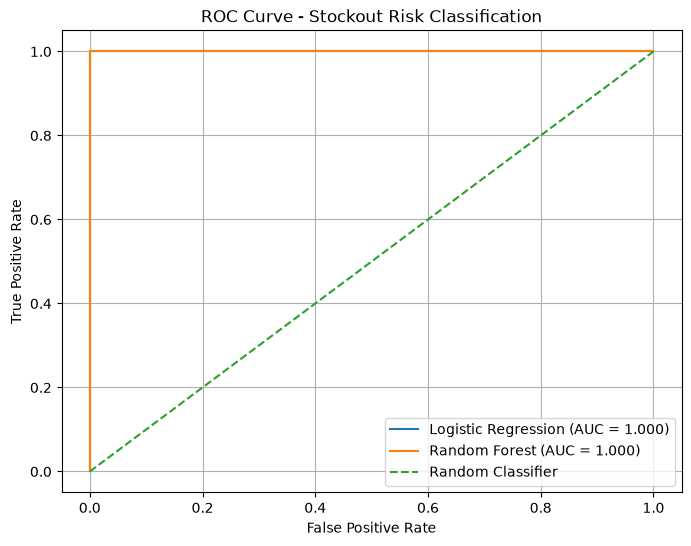

In [30]:
# ===== ROC CURVE COMPARISON =====

import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# Calculate ROC curve for Logistic Regression
logistic_fpr, logistic_tpr, _ = roc_curve(
    y_test_class,
    logistic_prob
)

# Calculate ROC curve for Random Forest
rf_fpr, rf_tpr, _ = roc_curve(
    y_test_class,
    rf_class_prob
)

# Calculate AUC
logistic_auc = auc(logistic_fpr, logistic_tpr)
rf_auc = auc(rf_fpr, rf_tpr)

# Plot ROC curves
plt.figure(figsize=(8, 6))

plt.plot(
    logistic_fpr,
    logistic_tpr,
    label=f"Logistic Regression (AUC = {logistic_auc:.3f})"
)

plt.plot(
    rf_fpr,
    rf_tpr,
    label=f"Random Forest (AUC = {rf_auc:.3f})"
)

# Random classifier reference line
plt.plot(
    [0, 1],
    [0, 1],
    linestyle="--",
    label="Random Classifier"
)

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve - Stockout Risk Classification")

plt.legend(loc="lower right")
plt.grid(True)
plt.show()

<Figure size 700x600 with 0 Axes>

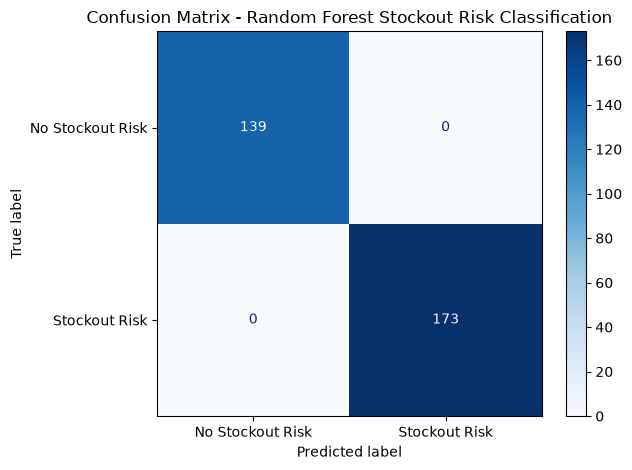

In [31]:
# ===== CONFUSION MATRIX VISUALIZATION =====

from sklearn.metrics import ConfusionMatrixDisplay

plt.figure(figsize=(7, 6))

ConfusionMatrixDisplay.from_predictions(
    y_test_class,
    rf_class_pred,
    display_labels=["No Stockout Risk", "Stockout Risk"],
    cmap="Blues"
)

plt.title("Confusion Matrix - Random Forest Stockout Risk Classification")
plt.tight_layout()
plt.show()

In [32]:
# ===== SAVE CLASSIFICATION RESULTS =====

classification_results = classification_comparison.copy()

classification_results["Accuracy (%)"] = (
    classification_results["Accuracy"] * 100
).round(2)

classification_results["Precision (%)"] = (
    classification_results["Precision"] * 100
).round(2)

classification_results["Recall (%)"] = (
    classification_results["Recall"] * 100
).round(2)

classification_results["F1 Score (%)"] = (
    classification_results["F1 Score"] * 100
).round(2)

classification_results["ROC-AUC"] = (
    classification_results["ROC-AUC"]
).round(4)

print("===== FINAL CLASSIFICATION RESULTS =====")
print(
    classification_results[
        [
            "Model",
            "Accuracy (%)",
            "Precision (%)",
            "Recall (%)",
            "F1 Score (%)",
            "ROC-AUC"
        ]
    ].to_string(index=False)
)

# Save to CSV
classification_results.to_csv(
    "classification_model_results.csv",
    index=False
)

print("\nSaved as: classification_model_results.csv")

===== FINAL CLASSIFICATION RESULTS =====
              Model  Accuracy (%)  Precision (%)  Recall (%)  F1 Score (%)  ROC-AUC
Logistic Regression         99.68          99.43       100.0         99.71      1.0
      Random Forest        100.00         100.00       100.0        100.00      1.0

Saved as: classification_model_results.csv


In [33]:
# ===== FINAL RISK SCORING NOTEBOOK AUDIT =====

print("===== 05_risk_scoring.ipynb : DATAFRAME AUDIT =====")

dataframes_to_check = {
    "sales": sales,
    "inventory": inventory,
    "inventory_10k": inventory_10k,
    "weekly_sku": weekly_sku,
    "avg_weekly_demand": avg_weekly_demand,
    "risk_data": risk_data,
    "risk_summary": risk_summary,
    "action_summary": action_summary,
    "baseline_data": baseline_data,
    "latest_forecast": latest_forecast,
    "final_risk_table": final_risk_table,
    "classification_results": classification_results
}

for name, df in dataframes_to_check.items():
    print(f"{name:25s} -> {df.shape}")

print("\n===== KEY OUTPUT FILES =====")

import os

files_to_check = [
    "final_forecast_output.csv",
    "classification_model_results.csv"
]

for file_name in files_to_check:
    print(
        f"{file_name:35s} -> "
        + ("EXISTS" if os.path.exists(file_name) else "NOT FOUND")
    )

===== 05_risk_scoring.ipynb : DATAFRAME AUDIT =====
sales                     -> (10000, 11)
inventory                 -> (21228, 6)
inventory_10k             -> (1556, 6)
weekly_sku                -> (198856, 7)
avg_weekly_demand         -> (3482, 2)
risk_data                 -> (1556, 19)
risk_summary              -> (5, 4)
action_summary            -> (4, 2)
baseline_data             -> (108046, 7)
latest_forecast           -> (1470, 3)
final_risk_table          -> (1556, 15)
classification_results    -> (2, 10)

===== KEY OUTPUT FILES =====
final_forecast_output.csv           -> EXISTS
classification_model_results.csv    -> EXISTS


In [1]:
%whos

Interactive namespace is empty.


In [5]:
import joblib
import os
from sklearn.ensemble import RandomForestClassifier

# Train the model only if it does not already exist
if "rf_classifier" not in globals():
    if "X_train_class" not in globals() or "y_train_class" not in globals():
        raise RuntimeError(
            "rf_classifier is unavailable. Run the classification "
            "preparation and training cells first."
        )

    rf_classifier = RandomForestClassifier(
        n_estimators=200,
        max_depth=10,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1
    )

    rf_classifier.fit(
        X_train_class,
        y_train_class
    )

# Create models folder
os.makedirs("models", exist_ok=True)

# Save trained Random Forest classifier
joblib.dump(
    rf_classifier,
    "models/random_forest_classifier.joblib"
)

print("Random Forest model saved successfully!")
print("File: models/random_forest_classifier.joblib")

Random Forest model saved successfully!
File: models/random_forest_classifier.joblib


In [8]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
import numpy as np
import pandas as pd

rf_classifier = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_leaf=2,
    random_state=42,
    n_jobs=-1
)

# Recreate the training data if the preparation cells were not executed
if "X_train_class" not in globals() or "y_train_class" not in globals():

    target_col = "stockout_risk"

    drop_cols = [
        "stockout_risk",
        "below_safety_risk",
        "reorder_risk",
        "risk_category",
        "final_risk_category",
        "final_recommended_action",
        "overstock_risk",
        "demand_source",
        "forecast_reference_date",
        "last_restock_date",
        "store_id",
        "sku_id"
    ]

    # Recreate risk_data when it is unavailable
    if "risk_data" not in globals():

        sales = pd.read_csv("../data/sales_10k_clean.csv")
        inventory = pd.read_csv(
            "../data/retail_clean_dataset/inventory_snapshot.csv"
        )

        sales["date"] = pd.to_datetime(
            sales["date"],
            errors="coerce"
        )

        sales_pairs = sales[
            ["store_id", "sku_id"]
        ].drop_duplicates()

        inventory_10k = inventory.merge(
            sales_pairs,
            on=["store_id", "sku_id"],
            how="inner"
        )

        risk_data = inventory_10k.copy()

        risk_data["stockout_risk"] = (
            risk_data["stock_on_hand"] <= 0
        )

    classification_data = risk_data.drop(
        columns=drop_cols,
        errors="ignore"
    )

    X_class = classification_data.drop(
        columns=[target_col],
        errors="ignore"
    )

    y_class = risk_data[target_col].astype(int)

    imputer = SimpleImputer(strategy="median")
    X_class_imputed = pd.DataFrame(
        imputer.fit_transform(X_class),
        columns=X_class.columns,
        index=X_class.index
    )

    X_train_class, X_test_class, y_train_class, y_test_class = train_test_split(
        X_class_imputed,
        y_class,
        test_size=0.20,
        random_state=42,
        stratify=y_class
    )

rf_classifier.fit(X_train_class, y_train_class)

print("Model fitted successfully!")

Model fitted successfully!


In [9]:
print("Number of trees:", len(rf_classifier.estimators_))
print("Model is fitted successfully.")

Number of trees: 200
Model is fitted successfully.


In [10]:
import joblib
import os

os.makedirs("models", exist_ok=True)

model_path = "models/random_forest_classifier.joblib"

joblib.dump(rf_classifier, model_path)

print("Fitted Random Forest model saved successfully!")
print("Saved at:", model_path)

Fitted Random Forest model saved successfully!
Saved at: models/random_forest_classifier.joblib


In [11]:
loaded_model = joblib.load(
    "models/random_forest_classifier.joblib"
)

print("Loaded model trees:", len(loaded_model.estimators_))
print("Model loaded and fitted successfully.")

Loaded model trees: 200
Model loaded and fitted successfully.


In [12]:
print("Features used for training:")
print(X_train_class.columns.tolist())

Features used for training:
['stock_on_hand', 'reorder_point', 'safety_stock']


In [13]:
print("\nNumber of features:", X_train_class.shape[1])



Number of features: 3
